In [1]:
import seaborn as sns
import scanpy as sc
import os
import anndata as ad
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math

import os
import pickle


%matplotlib inline
sc.settings.verbosity = 0
def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata.var_names]
    return LIST




In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
#%matplotlib inline
sc.settings.figdir = "fig6"
sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(8,8))


# scRNA

In [3]:
PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_T_ILC_atlas_scrna2.h5ad'
adata=sc.read_h5ad(PATH)
adata.shape

(382782, 36601)

In [4]:
# adata= adata[adata.obs["dataset_id"]!="GSE264508_GSE264508"].copy()
# PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_T_ILC_atlas_scrna2.h5ad'
# adata.write(PATH)

In [5]:
adata.obs["Patient_status"].nunique()

28

In [6]:
file_path = "/nfs/team298/ls34/color_for_adult_skin2.pkl"

with open(file_path, "rb") as f:
    palette_dict = pickle.load(f)         
    
colors = palette_dict

In [7]:
NEW_CELLS = {
    "Th2": "#2A6072",      # Dark Blue (classic, strong contrast)
    "Tfh-like": "#AAA9A9",  # Neon Blue (bright, electric tone)
    "Th17": "#FFB3B3",
     #   "TRM_IL13+": "#7D93C7"
    
}
             
palette_dict = palette_dict | NEW_CELLS
adata.obs['lvl4_annotation'] =adata.obs['lvl4_annotation'] .astype('category') 
adata.uns['lvl4_annotation_colors'] = [palette_dict.get(cat, '#D3D3D3')  for cat in adata.obs['lvl4_annotation'].cat.categories]



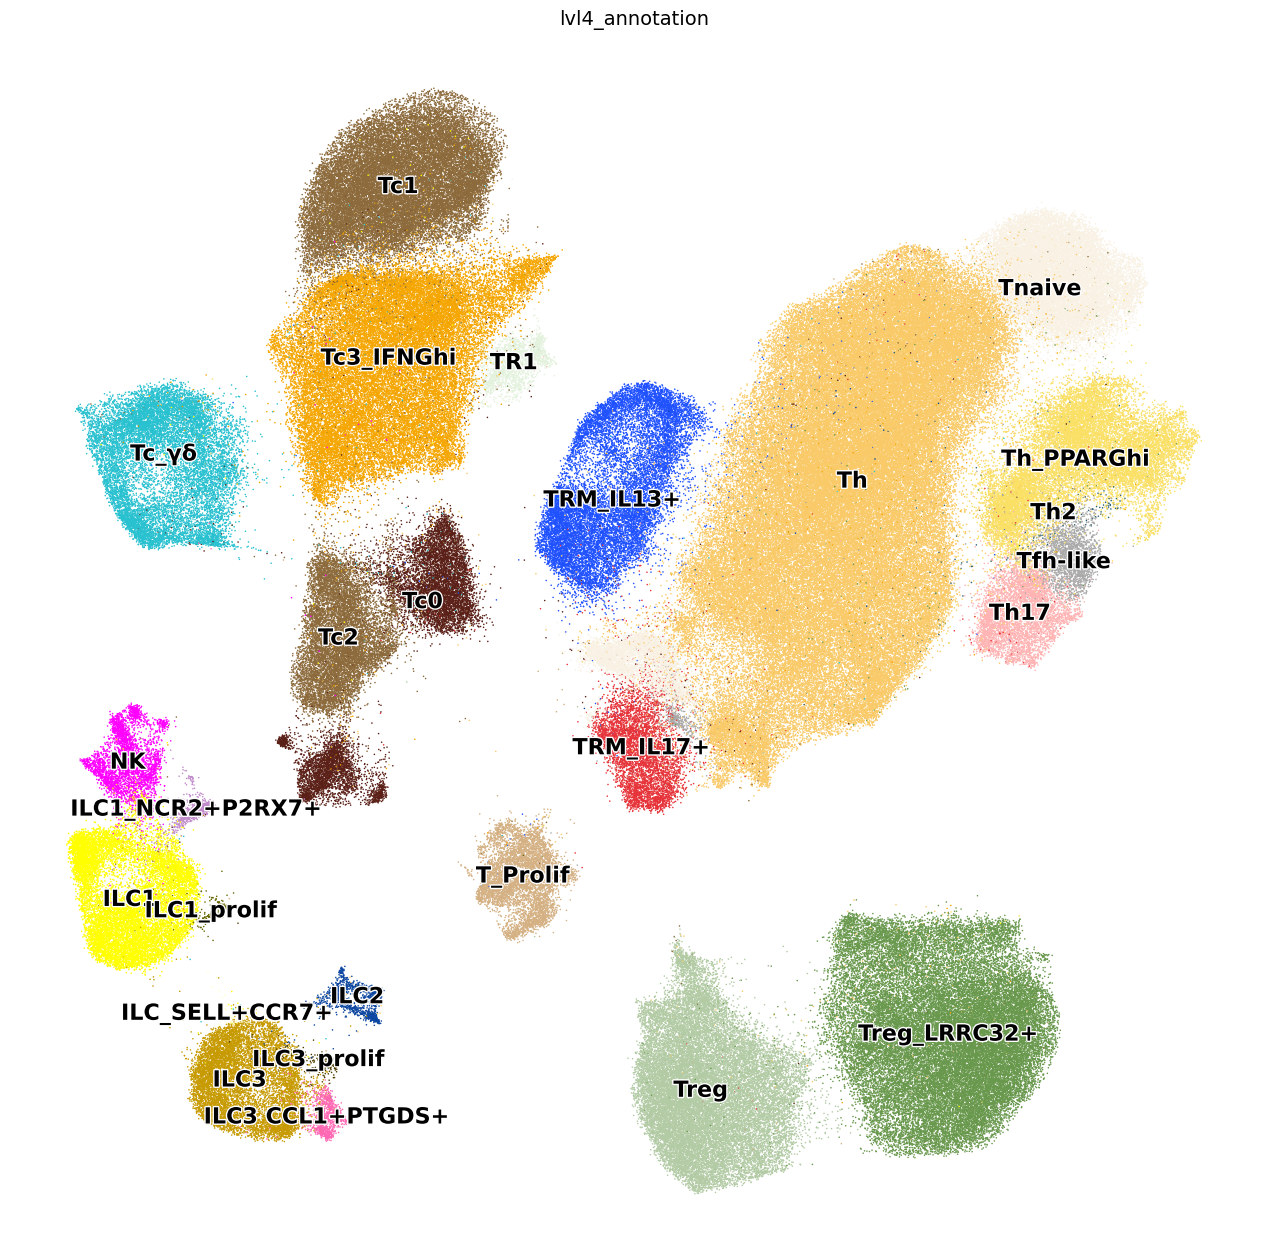

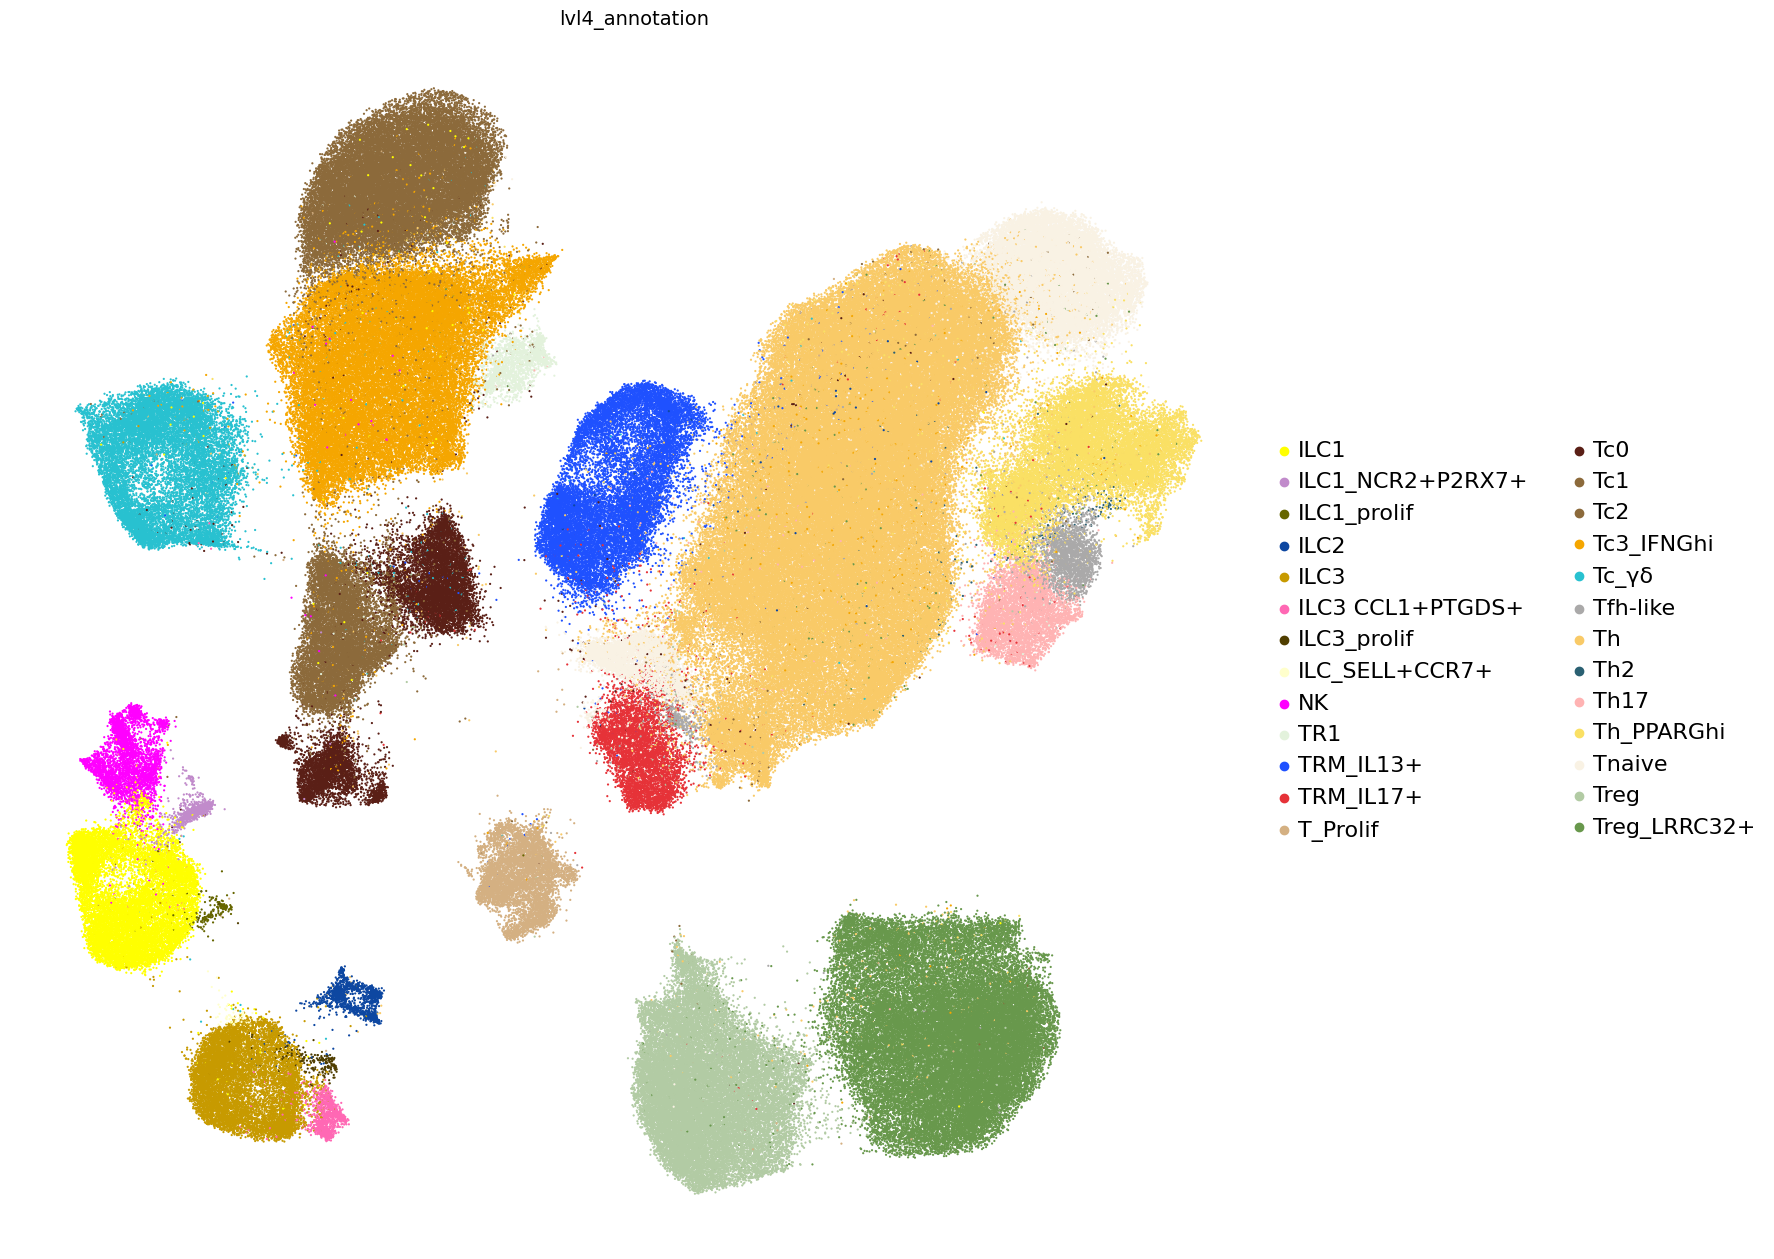

In [8]:
sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(16,16))

sc.pl.umap(
    adata,
    color=[
        'lvl4_annotation',  
    ],
    legend_loc="on data",
    s=5, 
    legend_fontoutline=2,
    legend_fontsize=16,
        save="6d_umap.pdf"

)

sc.pl.umap(
    adata,
    color=[
        'lvl4_annotation',  
    ],
    #legend_loc="on data",
    s=10, 
    legend_fontoutline=2,
    legend_fontsize=16
)


# tfh like (supp 13d/e)

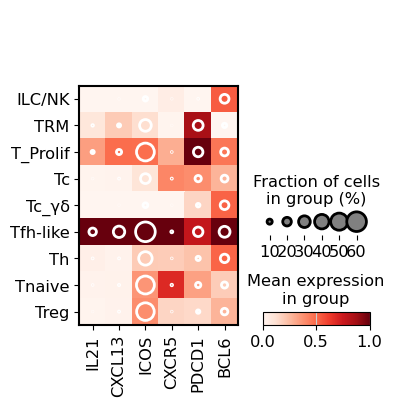

In [9]:
TFH_GENES =['IL21', "CXCL13", "ICOS", 'CXCR5', 'PDCD1', 'BCL6', 
           ]

dp =sc.pl.DotPlot(adata, 
              TFH_GENES,
              groupby="tfh_plot",
                 standard_scale="var",
            #ot_max=.7,
                      vmax=1,
           #categories_order = ORDER, #[x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
             # save="T_scrna.pdf",
                          # colorbar_title="Mean expression\n(minmax norm.)"

             ) 

dp =  dp.style(cmap='Reds', color_on='square', dot_edge_color='white', dot_edge_lw=2, grid=False, #vmax=.8
               dot_max=.6)
          
dp.savefig("fig6/tfh_dotplot.pdf", dpi=300)       
    

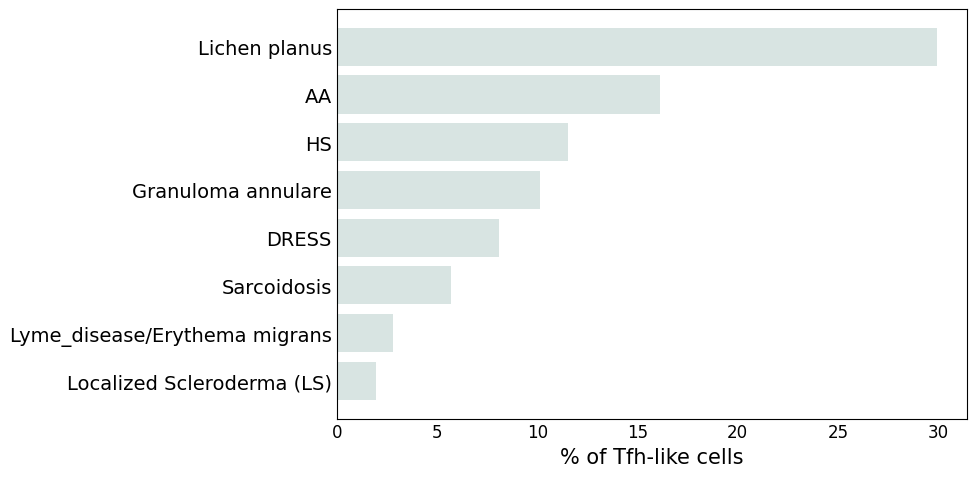

In [10]:
adata=adata[adata.obs["Patient_status2"]!="Nonlesional"].copy()
mask    = adata.obs["lvl4_annotation"] == "Tfh-like"
tfh_obs = adata.obs[mask]

disease_pct = (
    tfh_obs["Patient_status2"]
    .value_counts(normalize=True)
    .mul(100)
    .nlargest(8)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 5))   #

ax.barh(
    disease_pct.index,
    disease_pct.values,
    color="#d8e4e2"
)

ax.set_xlabel("% of Tfh-like cells", fontsize=15)  # larger x-label font
ax.set_ylabel("")
ax.tick_params(axis="x", labelsize=12, length=0)
ax.tick_params(axis="y", length=0)
ax.grid(False)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(True)

plt.tight_layout()


fig.savefig("fig6/6d_Tfh_contributors.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Fig 4f (TRMs)

In [11]:
adata_iii = adata[adata.obs["Site_status"] == "Lesional"].copy()

mask_13 = adata_iii.obs["lvl4_annotation"].str.startswith("TRM_IL13")
mask_17 = adata_iii.obs["lvl4_annotation"].str.startswith("TRM_IL17")


ds_col = "Patient_status"

tmp = pd.DataFrame({
    ds_col:         adata_iii.obs[ds_col].values,
    "TRM_IL13+":    mask_13.values.astype(int),
    "TRM_IL17+":    mask_17.values.astype(int)
})

counts   = tmp.groupby(ds_col)[["TRM_IL13+", "TRM_IL17+"]].sum()
totals   = tmp.groupby(ds_col).size()
props    = counts.div(totals, axis=0)


TOP_N=8

props_sorted = (
    props
    .nlargest(TOP_N, "TRM_IL13+")
    .sort_values(by=["TRM_IL13+", "TRM_IL17+"], ascending=[True, True])
)

# totals_top8 = totals.loc[props_sorted.index]

# def first_colour_starting_with(prefix, palette, default):
#     for k, v in palette.items():
#         if k.startswith(prefix):
#             return v
#     return default

# trm_cols   = ["TRM_IL13+", "TRM_IL17+"]
# other_cols = [c for c in props.columns if c not in trm_cols]
# plot_cols  = trm_cols + other_cols

# palette = [
#     "#FFFFFF" if c == "Other"
#     else first_colour_starting_with(c, colors, "#D3D3D3")
#     for c in plot_cols
# ]



# sns.set_theme(style="white")
# fig, ax = plt.subplots(figsize=(6, 8))

# left = np.zeros(len(props_sorted))
# for idx, c in enumerate(plot_cols):
#     ax.barh(
#         props_sorted.index,
#         props_sorted[c],
#         left=left,
#         color=palette[idx],
#         edgecolor="none",
#         linewidth=0,
#         label=None if c == "Other" else c
#     )
#     left += props_sorted[c]



# ax.set_xlabel(
#     "% of T cells in disease",
#     fontsize=16,
#     loc="left"             # ← shift label to the left
# )


# ax.xaxis.set_label_coords(-0.02, -0.07)   # x, y in axes fraction

# ax.set_xlim(0, 0.25)
# ax.set_xticks([0, 0.1, 0.2])
# ax.set_xticklabels([f"{p:.0%}" for p in [0, 0.1, 0.2]], fontsize=18)
# ax.tick_params(axis="x", which="major", length=6, width=1.2, labelsize=18)

# totals_ILCs = counts.sum(axis=1)   # total ILCs per disease
# totals_top10 = totals_ILCs.loc[props_sorted.index]

# yticklabels = [
#     f"{d}_n={n:,}" if n >= 10_000 else f"{d}_n={n}"
#     for d, n in totals_top8.items()
# ]
# ax.set_yticklabels(
#     [f"{d}_n={totals_top10[d]:,}" for d in props_sorted.index],
#     fontsize=14
# )
# ax.set_ylabel("")

# for spine in ["top", "right", "left", "bottom"]:
#     ax.spines[spine].set_visible(True)

# handles, labels = ax.get_legend_handles_labels()
# ax.legend(
#     handles, labels,
#     bbox_to_anchor=(.4, .98),
#     loc="lower center",
#     ncol=1,
#     frameon=False,
#     fontsize=18
# )

# plt.tight_layout()
# plt.savefig(
#     "figures/fig3e_TRM_bypatientstatus_topbars_fixedxlabel2.pdf",
#     dpi=300, bbox_inches="tight"
# )
# plt.show()

/tmp/ipykernel_1342608/594418620.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts   = tmp.groupby(ds_col)[ILC_TYPES].sum()
/tmp/ipykernel_1342608/594418620.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  totals   = tmp.groupby(ds_col).size()
/tmp/ipykernel_1342608/594418620.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(yticklabels, fontsize=24)


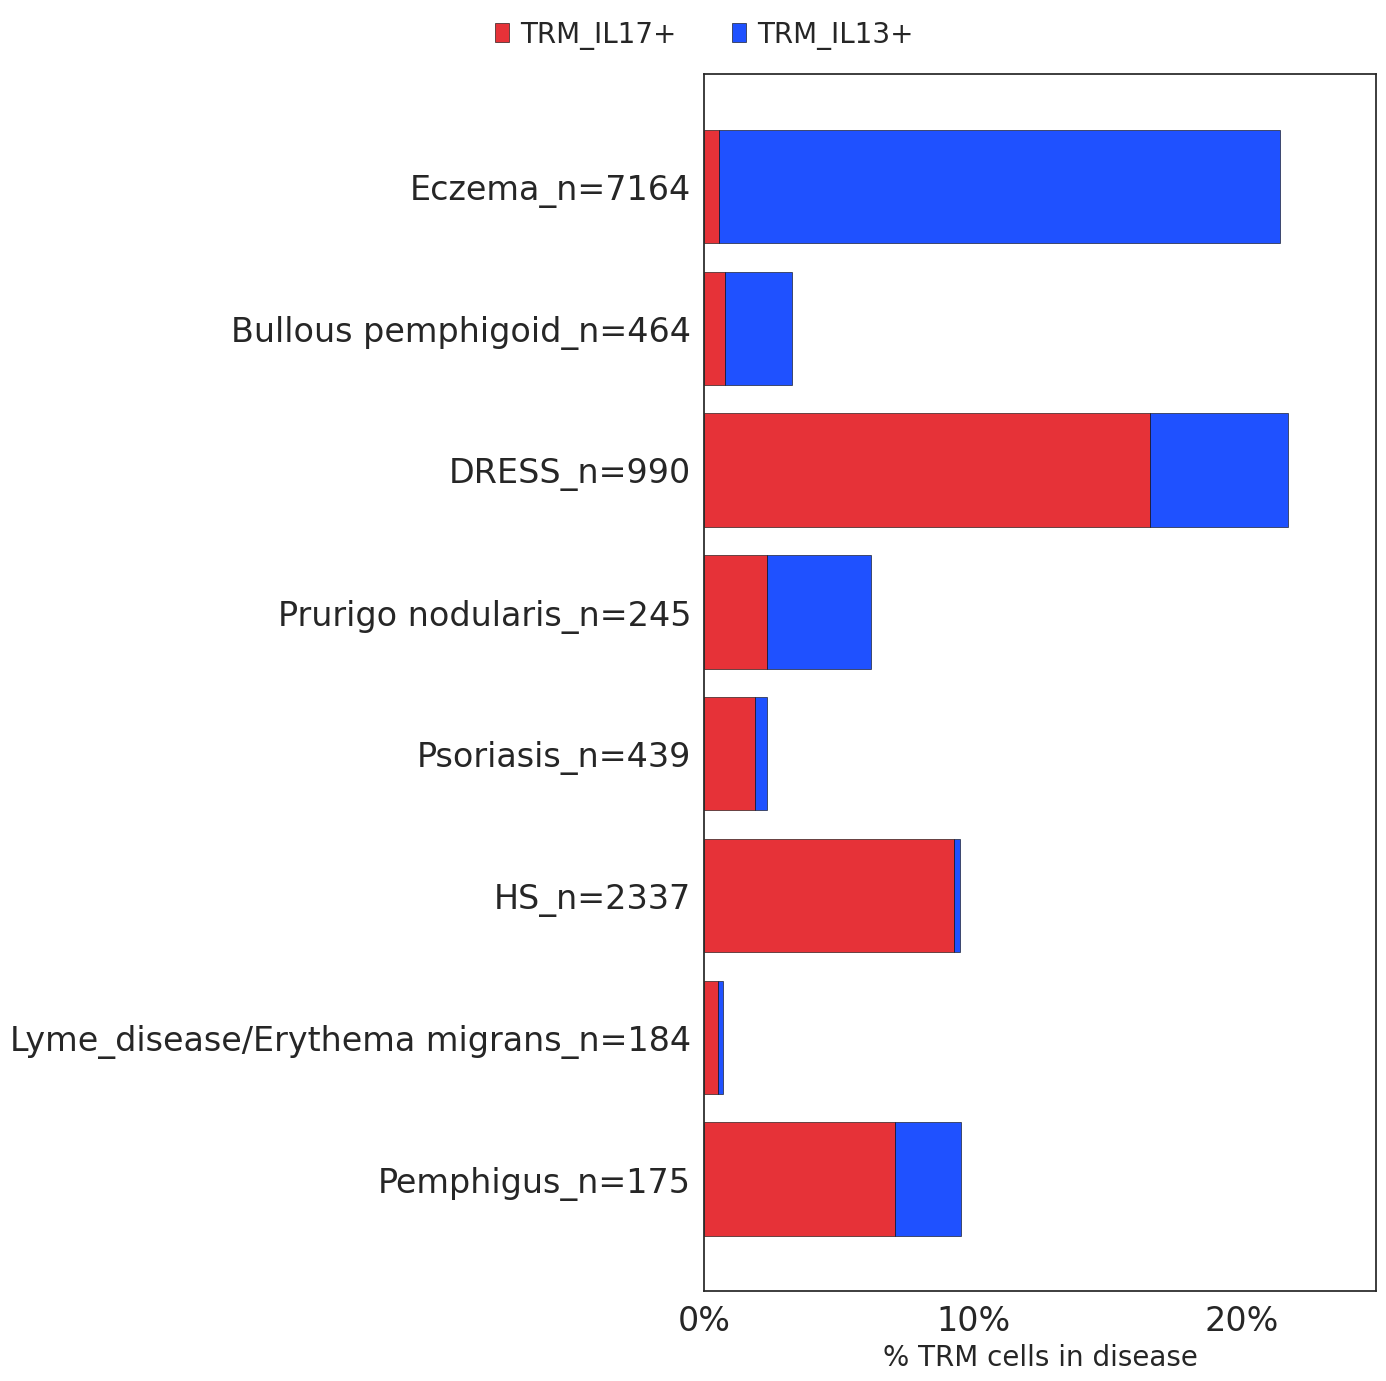

In [13]:
TOP_N=8

#adata_iii = adata[adata.obs["Site_status"] == "Lesional"]

ILC_TYPES = [
    "TRM_IL17+",  "TRM_IL13+", 
]

obs_labels = adata_iii.obs["lvl4_annotation"]
masks = {ct: obs_labels.str.startswith(ct) for ct in ILC_TYPES}

ds_col = "Patient_status"

df_dict = {ds_col: adata_iii.obs[ds_col].values}
for ct in ILC_TYPES:
    df_dict[ct] = masks[ct].values.astype(int)

tmp      = pd.DataFrame(df_dict)
counts   = tmp.groupby(ds_col)[ILC_TYPES].sum()
totals   = tmp.groupby(ds_col).size()
props    = counts.div(totals, axis=0)

top8_diseases = (
    counts
    .nlargest(TOP_N, "TRM_IL13+")
    .index
)

#totals_top8  = totals.loc[props_sorted.index]
props_sorted = props.loc[top8_diseases, ILC_TYPES]

props_sorted = props_sorted.loc[
    counts.loc[top8_diseases].sort_values("TRM_IL13+", ascending=True).index
]

def lookup(name, palette, default="#D3D3D3"):
    for k, v in palette.items():
        if k.startswith(name):
            return v
    return default

palette = [lookup(ct, colors) for ct in ILC_TYPES]

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(14, 14))

left = np.zeros(len(props_sorted))
for idx, ct in enumerate(ILC_TYPES):
    ax.barh(
        props_sorted.index,
        props_sorted[ct],
        left=left,
        color=palette[idx],
        edgecolor="black", linewidth=0.4,
        label=ct
    )
    left += props_sorted[ct]

ax.set_xlabel("% TRM cells in disease", fontsize=20)
ax.set_ylabel("")
ax.set_xlim(0, 0.25)
ax.set_xticks([0, 0.1, 0.2])
ax.set_xticklabels([f"{p:.0%}" for p in [0, 0.1, 0.2]], fontsize=24)
ax.tick_params(axis="x", which="major", length=6, width=1.2, labelsize=24)

totals_ILCs = counts.sum(axis=1)
totals_top8 = totals_ILCs.loc[props_sorted.index]

yticklabels = [
    f"{d}_n={n:,}" if n >= 10_000 else f"{d}_n={n}"
    for d, n in totals_top8.items()
]
yticklabels = [
    f"{d}_n={n:,}" if n >= 10_000 else f"{d}_n={n}"
    for d, n in totals_top8.items()
]
ax.set_yticklabels(yticklabels, fontsize=24)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(True)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, labels,
    bbox_to_anchor=(0.0, 1.0),
    loc="lower center",
    ncol=5,
    frameon=False,
    fontsize=20
)

plt.tight_layout()
plt.savefig(
    "figures/fig3e_TRM_bypatientstatus_topbars_fixedxlabel2.pdf",
    dpi=300, bbox_inches="tight"
)
plt.show()

In [14]:
T_DICT = {   "Tissue-residency\n markers": ["CD4", "CD8A", "ITGAE",  "CD109", 'ZNF683', "ENTPD1", # "RBPJ"
                                        "ITGAV"
                                       ],
# 'IL22': ['IL22', 'IL13', 'PDLIM4', #'KRT7',
#         # "NBAS", 
#          'CCL1', #"CCL17", 
#          "AREG", "CCR8", "IL9R", #"CCR4", "CCR10"
#         ],
 'T_17': [ 'IL17A', 'IL17F', 'CXCL13', 'IL26', "IL21", 'CCL20', 'CTSH', "IL23R",
         "CCR6","RORC", 'TNFRSF8', "ADAM12", #"IL1R1", #"IL12RB2",
            'LRRN3',         'MYO7A',  "VDR", #"CD38",
       
         ],
         "Other": [    "PTPN13","ITGA1", "IFNG"],
         # "ITGA1hi": ["ITGA1", 
         #             'ZHX2',# 'TRPS1', 'TBC1D22A', 'ABLIM1', 
         #             'BICD1',#'MVB12B', 
         #             'PRR5L', # 'PCNX4', 'EPHA4', 
         #             'ST8SIA1', 
         #             'ZNF407',],
         #"Memory": ["CD69",],
#               'Gamma-delta': ["FXYD2", "TRGC2", 'TRDV1','TRGV4',  "EMP1",
#                              "NSG1", #"LINC02446","CD9", 
#                               "MPZL2", "KLRC2"], #'TRGC2', 
          
          "TRM1" : ["CTSH", "MAPKAPK3", "RTL8C", "KAT5", 
        "SMARCD3", "SV2C", "UBXN6", "PHEX", "ZNF524", "UBQLN4", "EXOSC4", "CAMK1", "NKIRAS2", "ANKRD40",
        "ZNF23", "COPG2", "PARP6", "IL13", "CRMP1", "DUSP12", "MAK16", "RCAN1", "PTGES2", "CCDC22", "TCEANC2", "RYR1",
        "AP1S1", "NME6",  "UMPS",
        "HMOX1", "EGLN3", "ITGB8", "SORD", "RNF135", "CCL20", "COL6A3", "MMAB", "C3orf14", "LRRC1",
        "ZNF71", "PCBP4", "FAM86C1", "DRICH1", "RTKN", 
        
        
        
       ]}


In [15]:
mask_13 = adata_iii.obs["lvl4_annotation"].str.startswith("TRM_IL13")
adata_iiii=adata_iii[mask_13]
adata_iiii.obs["lvl4_annotation"].value_counts()

lvl4_annotation
TRM_IL13+    8104
Name: count, dtype: int64

In [16]:
sc.pp.normalize_total(adata_iiii, target_sum=1e4)
sc.pp.log1p(adata_iiii)


/software/cellgen/team298/ls34/ccc_liana/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [17]:
T_DICT2 = {   "Tissue-residency\n markers": ["CD4", "CD8A", "ITGAE",  "CD109", 'ZNF683', "ENTPD1", # "RBPJ"
                                        "ITGAV"
                                       ],
'IL22': ['IL22', 'IL13', 'PDLIM4', #'KRT7',
        # "NBAS", 
         'CCL1', #"CCL17", 
         "AREG", "CCR8", "IL9R", #"CCR4", "CCR10"
        ],
 'T_17': [ 'IL17A', 'IL17F', 'CXCL13', 'IL26', "IL21", 'CCL20', 'CTSH', "IL23R",
         "CCR6","RORC", 'TNFRSF8', "ADAM12", #"IL1R1", #"IL12RB2",
            'LRRN3',         'MYO7A',  "VDR", #"CD38",
       
         ],
         "Other": [    "PTPN13","ITGA1", "IFNG"],
         # "ITGA1hi": ["ITGA1", 
         #             'ZHX2',# 'TRPS1', 'TBC1D22A', 'ABLIM1', 
         #             'BICD1',#'MVB12B', 
         #             'PRR5L', # 'PCNX4', 'EPHA4', 
         #             'ST8SIA1', 
         #             'ZNF407',],
         #"Memory": ["CD69",],
#               'Gamma-delta': ["FXYD2", "TRGC2", 'TRDV1','TRGV4',  "EMP1",
#                              "NSG1", #"LINC02446","CD9", 
#                               "MPZL2", "KLRC2"], #'TRGC2', 
          
        #   "TRM1" : ["CTSH", "MAPKAPK3", "RTL8C", "KAT5", 
        # "SMARCD3", "SV2C", "UBXN6", "PHEX", "ZNF524", "UBQLN4", "EXOSC4", "CAMK1", "NKIRAS2", "ANKRD40",
        # "ZNF23", "COPG2", "PARP6", "IL13", "CRMP1", "DUSP12", "MAK16", "RCAN1", "PTGES2", "CCDC22", "TCEANC2", "RYR1",
        # "AP1S1", "NME6",  "UMPS",
        # "HMOX1", "EGLN3", "ITGB8", "SORD", "RNF135", "CCL20", "COL6A3", "MMAB", "C3orf14", "LRRC1",
        # "ZNF71", "PCBP4", "FAM86C1", "DRICH1", "RTKN", 
        
        
        
       }


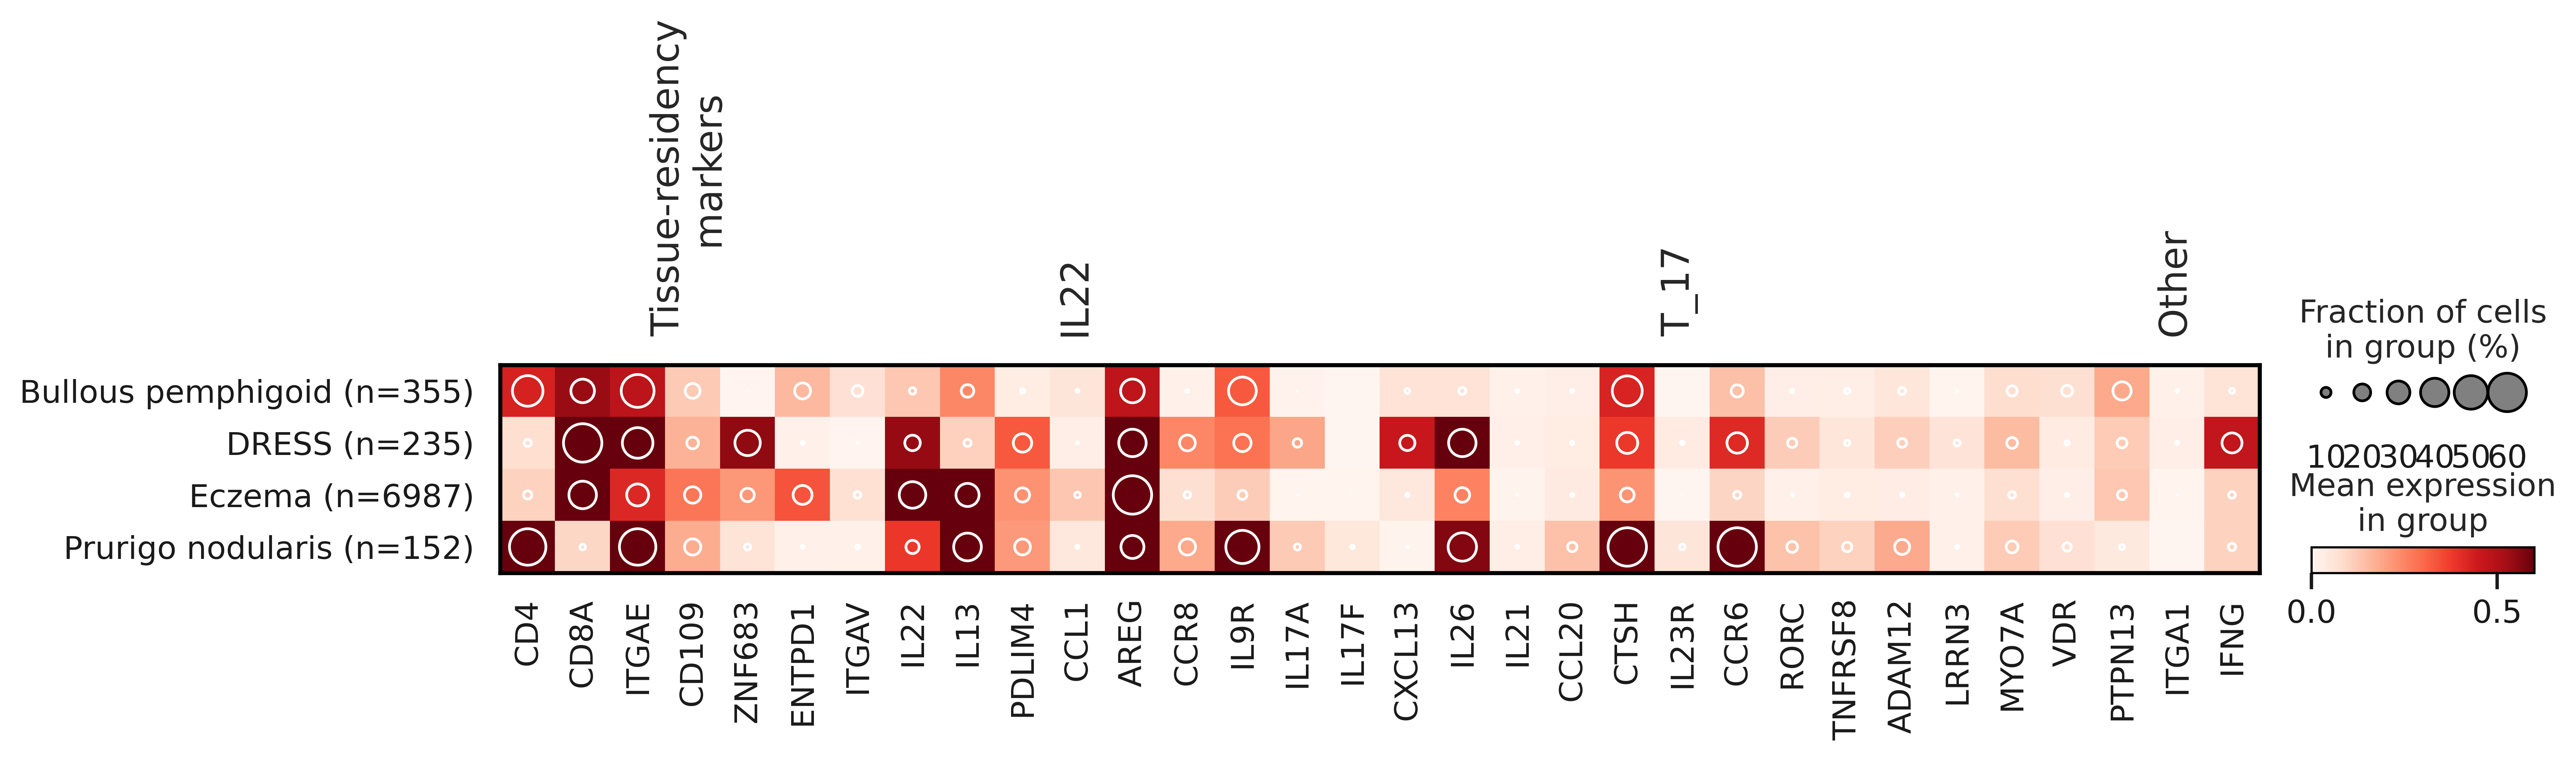

In [18]:
# Step 1: Count the number of cells per Patient_status
T2 = ["Eczema", "Prurigo nodularis", "Bullous pemphigoid", "DRESS"]
adata_iiii=adata_iiii[adata_iiii.obs["Patient_status"].isin(T2)]
counts = adata_iiii.obs["Patient_status"].value_counts()

# Step 2: Identify Patient_status values with at least 20 cells
valid_statuses = counts[counts >= 20].index

# Step 3: Filter the AnnData object
adata_iiii = adata_iiii[adata_iiii.obs["Patient_status"].isin(valid_statuses)].copy()
adata_iiii.obs["Patient_status"].value_counts()
# Step 1: Count cells per group
counts = adata_iiii.obs["Patient_status"].value_counts()

# Step 2: Build new labels like "PatientA (n=123)"
label_map = {group: f"{group} (n={count})" for group, count in counts.items()}

# Step 3: Add a new column with updated labels
adata_iiii.obs["Patient_status_labeled"] = adata_iiii.obs["Patient_status"].map(label_map)

# Step 4: Sort by counts descending
sorted_labels = [label_map[g] for g in counts.index]


sc.settings.set_figure_params(dpi=300, facecolor="white", frameon=False, figsize=(8,8))


sc.pl.DotPlot(
    adata_iiii,
   remove_markers(T_DICT2),
    #swap_axes=True,
    groupby='Patient_status_labeled',
   vmax=.6,
    #    colorbar_title='Mean expression\n(variance scaled)', 
   # standard_scale="var",
   # categories_order=["Treg", "Treg_LRRC32+", "TR1"]
) \
    .style(cmap='Reds', color_on='square', dot_edge_color='white', dot_edge_lw=1, grid=False, #vmax=.8
               dot_max=.6

          )\
.show()
sc.settings.set_figure_params(dpi=50,dpi_save=300, facecolor="white", frameon=False, figsize=(8,8))


# ilc

In [19]:
adata_iiii=adata_iii[ (adata_iii.obs["lvl4_annotation"].str.startswith("ILC3"))
                    ]
adata_iiii=adata_iiii[adata_iiii.obs["lvl4_annotation"]!="ILC3_prolif"]
adata_iiii.obs["lvl4_annotation"].value_counts()


lvl4_annotation
ILC3                3339
ILC3 CCL1+PTGDS+     445
Name: count, dtype: int64

In [20]:
sc.pp.normalize_total(adata_iiii, target_sum=1e4)
sc.pp.log1p(adata_iiii)


/software/cellgen/team298/ls34/ccc_liana/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [21]:
# Step 1: Count the number of cells per Patient_status
counts = adata_iiii[adata_iiii.obs["lvl4_annotation"]=="ILC3 CCL1+PTGDS+"].obs["Patient_status"].value_counts()

# Step 2: Identify Patient_status values with at least 20 cells
valid_statuses = counts[counts >= 5].index

# Step 3: Filter the AnnData object
adata_iiii = adata_iiii[adata_iiii.obs["Patient_status"].isin(valid_statuses)].copy()
adata_iiii.obs["Patient_status"].value_counts()
# Step 1: Count cells per group
counts = adata_iiii.obs["Patient_status"].value_counts()

# Step 2: Build new labels like "PatientA (n=123)"
label_map = {group: f"{group} (n={count})" for group, count in counts.items()}

# Step 3: Add a new column with updated labels
adata_iiii.obs["Patient_status_labeled"] = adata_iiii.obs["Patient_status"].map(label_map)

# Step 4: Sort by counts descending
sorted_labels = [label_map[g] for g in counts.index]


In [22]:
ILC1_CCL1_GENES = {"ILC3":   ['ID3','CSF2', 'KRT86',
 # 'ZBTB46',
  'TNFSF4',
  'SPINK2',
  'RAMP1',
  'MB',
  'KLRF2',
  'TMPRSS11E', "ZNF683"],
    
                    "Polarised": ["MB" ,"KRT86", "NEDD8", "EVL" , "KRT81", "ZNF683", "SIRPG", "PYCARD",
                  "MVP", "SDHC", "KRT14", "NME1", "NCR3", 
                   "CST6",
                  
                  ]}
# # Step 5: Plot
# sc.pl.dotplot(
#     adata_iiii,
#     ILC1_CCL1_GENES,
#     groupby="Patient_status_ILC3",
#     dendrogram=False,
#     standard_scale="var",
#     #categories_order=sorted_labels,
#    # dot_max=.6
# )

In [23]:
# adata_i=adata[adata.obs["lvl4_annotation"]=="ILC3_CCL1+PTGDS+"]


In [24]:
ALLT2 = {'Innate': [
  'KLRB1',
  'KLRC1',
  'TYROBP',
  'FCER1G',
],

          'ILC3': ['ID3','CSF2', 'KRT86',
 # 'ZBTB46',
  'TNFSF4',
  'SPINK2',
  'RAMP1',
  'MB',
  'KLRF2',
  'TMPRSS11E', "ZNF683"],
           'PTGDS': [  'PTGDS', 'PDLIM4', 'CCL1'],


 'ILC2+3': ['IL9R', 'TNFSF11'],
 'ILC2': ['GATA3',  'IL18R1','KIT', 'PTGDR2', 'TNFRSF25',
          'CRLF2',
  'IL17RB',
  'IL1RL1',
  'PPARG',
  'PTGS2',
  'PLA2G4A',

  'NRROS',     'IL31',
'IL22', 'IL13', 
         ],
 # 'Naive/Tcm': ['SELL', 'CCR7', 'S1PR1', 'TCF7', 'PAK2', 'ZHX2'],
 #        "NEW": ["PLXDC2", "AIF1", "RAB34", "NEDD4L", "PM20D2", "TNRC18", "JCHAIN", ],
 # 'Cycling': ['UBE2C', 'MKI67', 'TOP2A'],
 #        "RORC+": ["RORC",]
        }

             
adata_iiii=adata_iii[ (adata_iii.obs["lvl4_annotation"].str.startswith("ILC3 CCL"))|
                     (adata_iii.obs["lvl4_annotation"].str.startswith("ILC3_CCL"))
                    ]
adata_iiii.obs["lvl4_annotation"].value_counts()
sc.pp.normalize_total(adata_iiii, target_sum=1e4)
sc.pp.log1p(adata_iiii)

# Step 1: Count the number of cells per Patient_status
counts = adata_iiii.obs["Patient_status"].value_counts()

# Step 2: Identify Patient_status values with at least 20 cells
valid_statuses = counts[counts >= 5].index

# Step 3: Filter the AnnData object
adata_iiii = adata_iiii[adata_iiii.obs["Patient_status"].isin(valid_statuses)].copy()
adata_iiii.obs["Patient_status"].value_counts()
# Step 1: Count cells per group
counts = adata_iiii.obs["Patient_status"].value_counts()

# Step 2: Build new labels like "PatientA (n=123)"
label_map = {group: f"{group} (n={count})" for group, count in counts.items()}

# Step 3: Add a new column with updated labels
adata_iiii.obs["Patient_status_labeled"] = adata_iiii.obs["Patient_status"].map(label_map)

# Step 4: Sort by counts descending
sorted_labels = [label_map[g] for g in counts.index]



/software/cellgen/team298/ls34/ccc_liana/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [25]:
sorted(adata_iiii.obs["Patient_status_labeled"].unique())

['Bullous pemphigoid (n=19)',
 'Eczema (n=356)',
 'Lyme_disease/Erythema migrans (n=9)',
 'Prurigo nodularis (n=11)',
 'Psoriasis (n=32)',
 'Vitiligo (n=5)']

In [26]:
adata_iiii=adata_iiii[adata_iiii.obs["Patient_status_labeled"]!='Psoriasis (n=32)']

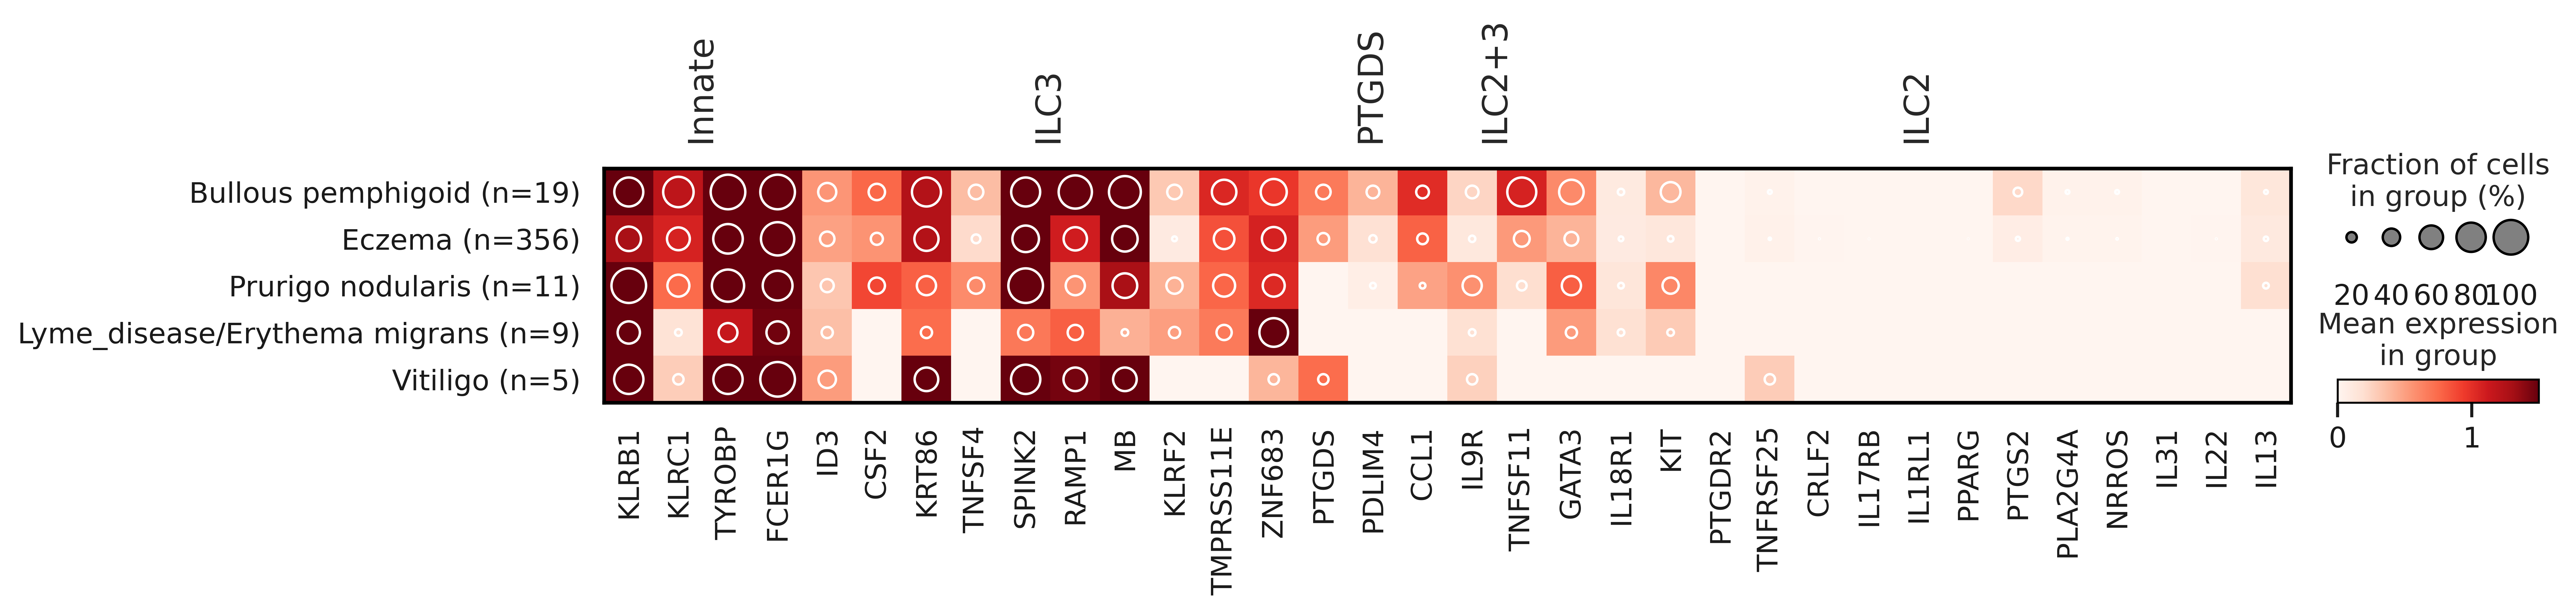

In [27]:
sc.settings.set_figure_params(dpi=300, facecolor="white", frameon=False, figsize=(8,8))

sc.pl.DotPlot(
    adata_iiii,
   remove_markers(ALLT2),
    #swap_axes=True,
    groupby="Patient_status_labeled",
   vmax=1.5,
    #    colorbar_title='Mean expression\n(variance scaled)', 
   # standard_scale="var",
    categories_order=['Bullous pemphigoid (n=19)',
 'Eczema (n=356)',
                       'Prurigo nodularis (n=11)',
# 'Psoriasis (n=32)',
 'Lyme_disease/Erythema migrans (n=9)',

 'Vitiligo (n=5)']
) \
    .style(cmap='Reds', color_on='square', dot_edge_color='white', dot_edge_lw=1, grid=False, #vmax=.8
               dot_max=1

          )\
.show()

sc.settings.set_figure_params(dpi=50,dpi_save=300, facecolor="white", frameon=False, figsize=(8,8))



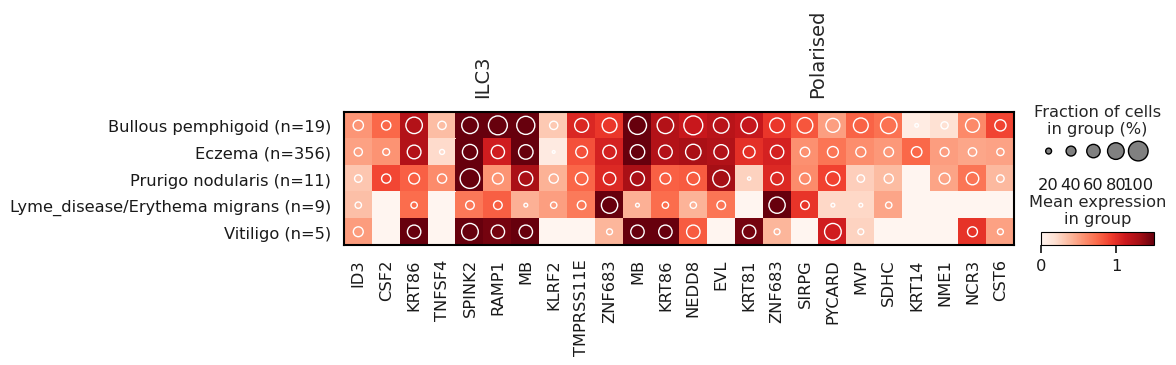

In [28]:
sc.pl.DotPlot(
    adata_iiii,
   remove_markers(ILC1_CCL1_GENES),
    #swap_axes=True,
    groupby="Patient_status_labeled",
   vmax=1.5,
    #    colorbar_title='Mean expression\n(variance scaled)', 
   # standard_scale="var",
    categories_order=['Bullous pemphigoid (n=19)',
 'Eczema (n=356)',
                       'Prurigo nodularis (n=11)',
# 'Psoriasis (n=32)',
 'Lyme_disease/Erythema migrans (n=9)',

 'Vitiligo (n=5)']
) \
    .style(cmap='Reds', color_on='square', dot_edge_color='white', dot_edge_lw=1, grid=False, #vmax=.8
               dot_max=1

          )\
.show()

In [29]:
stop

1

# Show all atlas

In [1]:
import scanpy as sc


In [6]:
adata=sc.read_h5ad('/nfs/team298/ls34/gold_adatas/adultskin/adata_skin_with_junk_forTcells.h5ad')
adata.shape


(3563082, 36601)

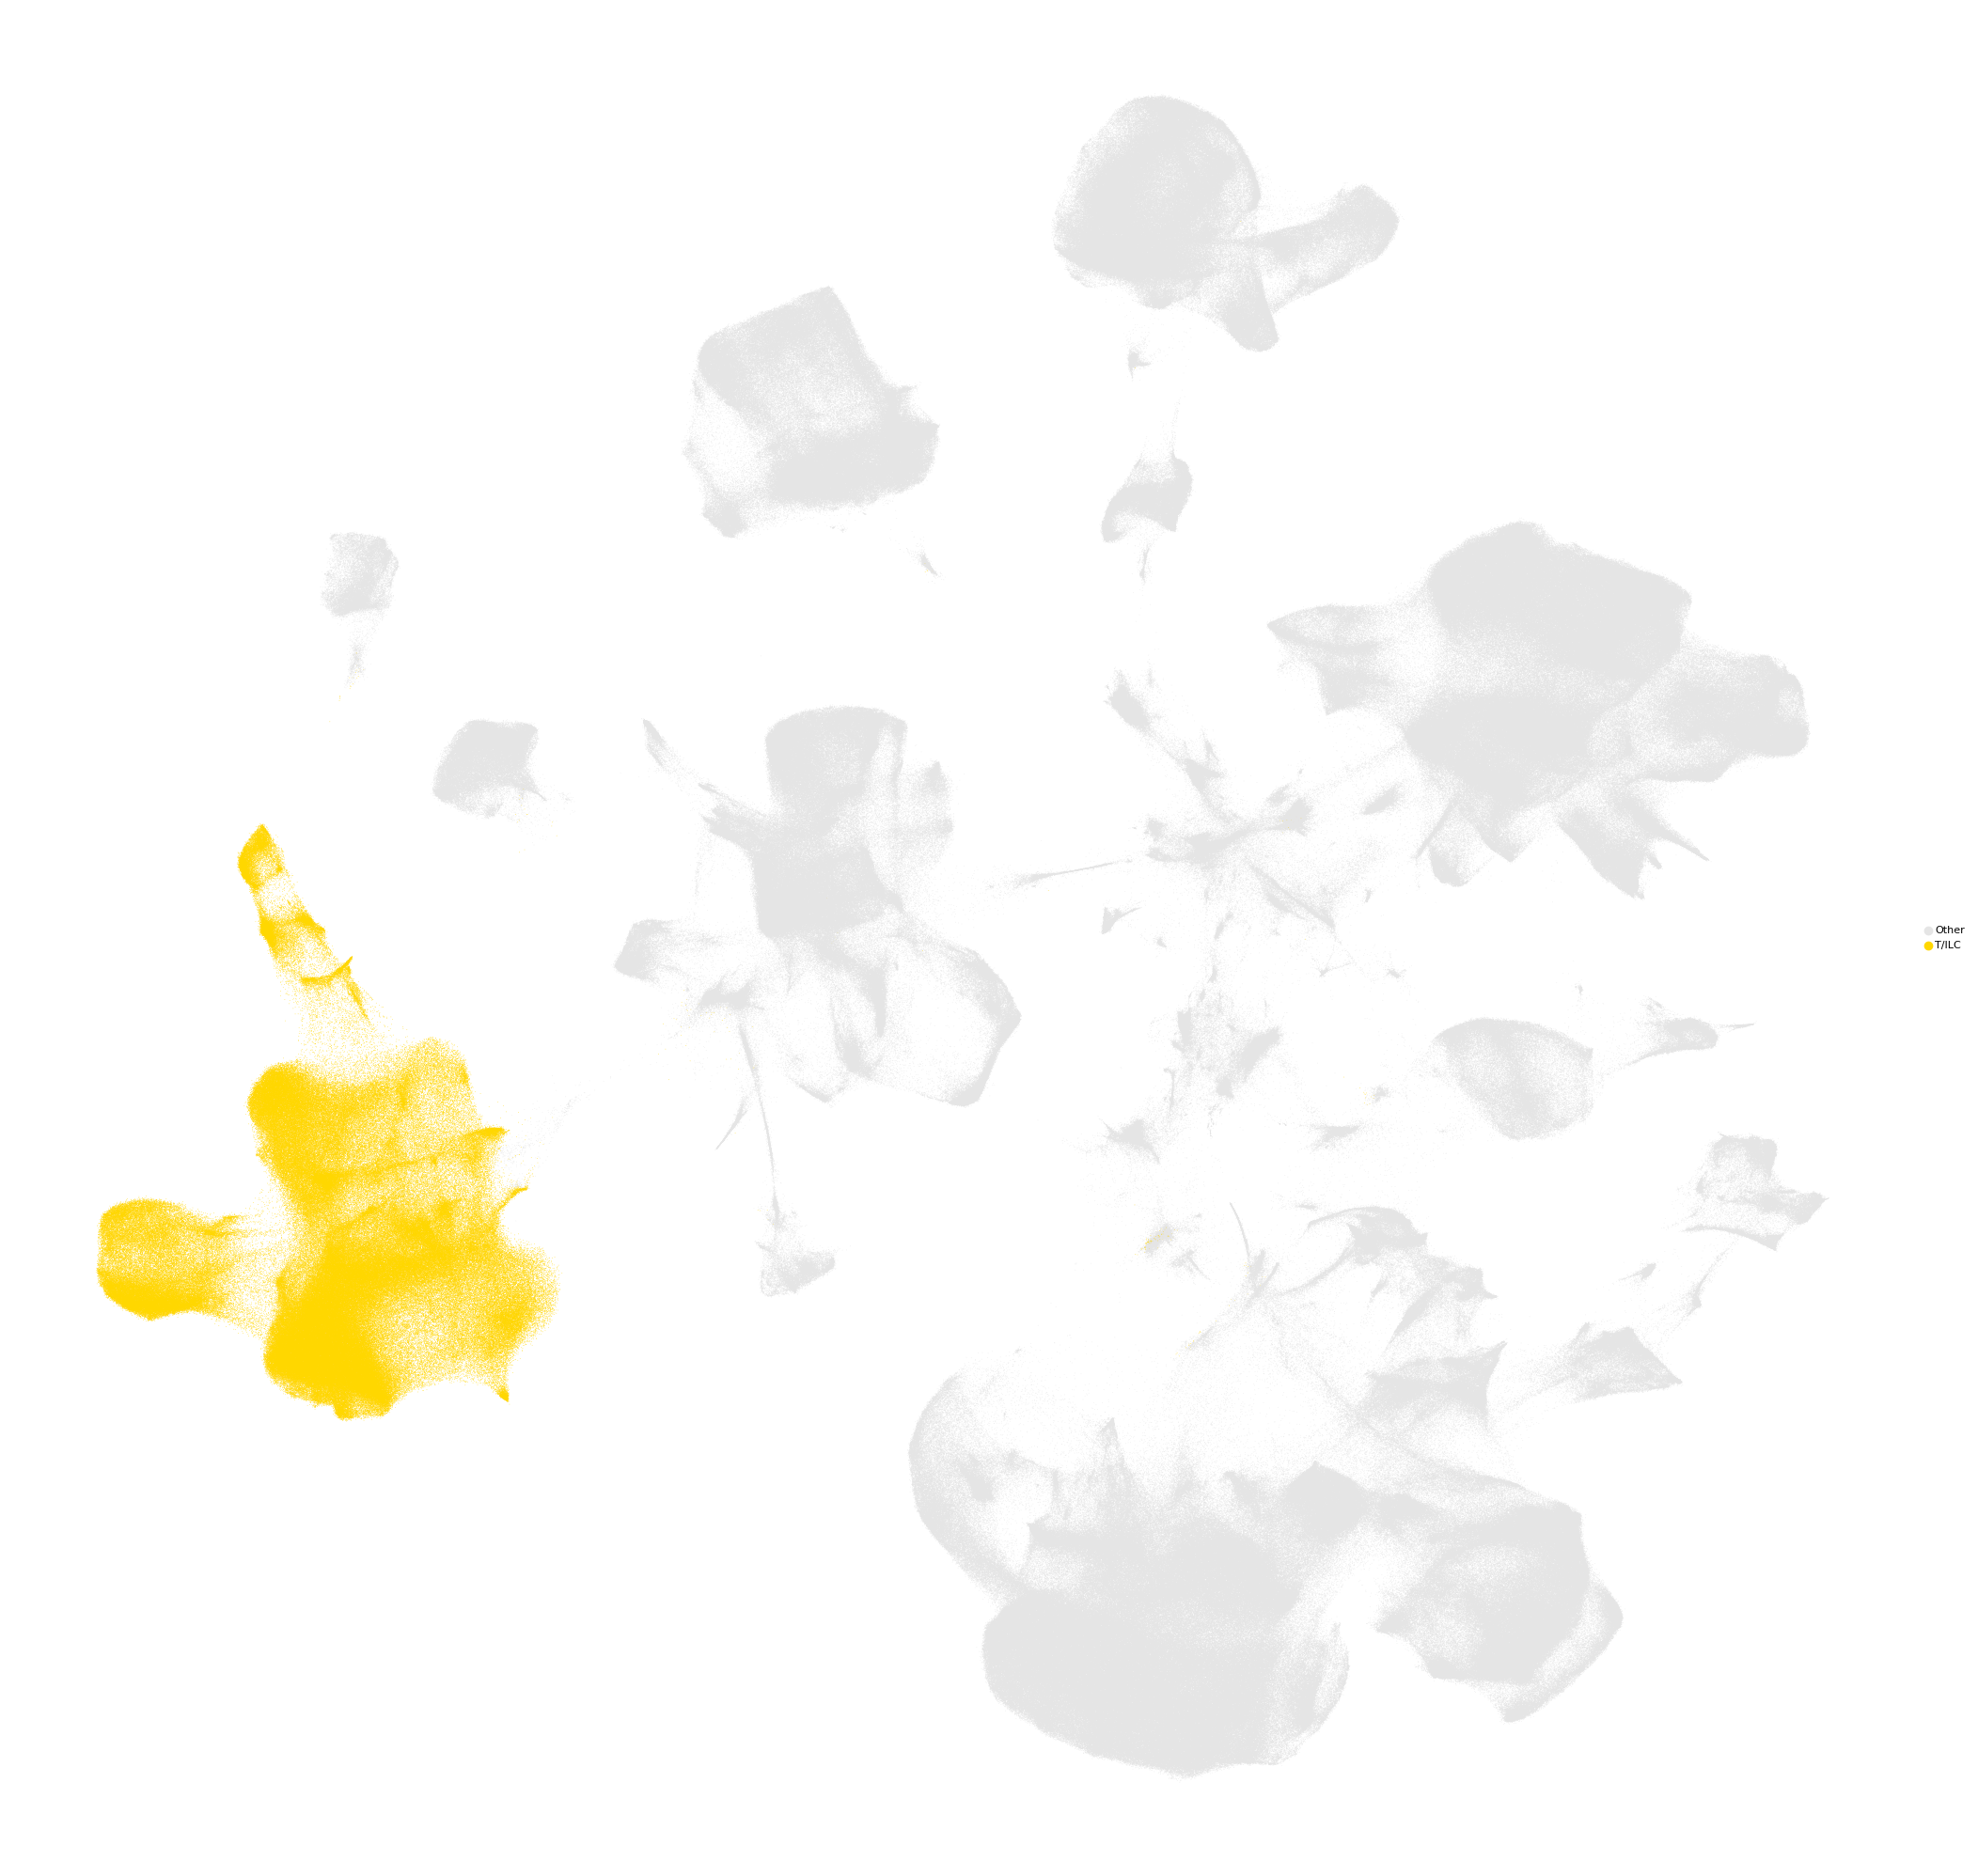

In [5]:
sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(26,26))

G_C = {
    "Other": "#E5E5E5",
    "T/ILC": "#FFD700"
}
sc.pl.umap(
    adata,
    color=[
   't_vs_other',
    ],
   # legend_loc="on data",
    s=1, 
    legend_fontoutline=2,
    legend_fontsize=8,
    palette=G_C,
    save="TILC_vs_other.pdf",
    title=""
)


 